## Построим GPT с нуля

В этом ноутбуке изучим как работает GPT под капотом

In [1]:
# Всегда начинаем с датасета на котором будем обучаться. 
# Так что давай загрузим the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-09-17 12:19:44--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-09-17 12:19:44 (22.4 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [2]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [3]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [4]:
# let's look at the first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



## Сначала токенизация!

In [5]:
# вытащим только уникальные символы и составим размер словарь
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [6]:
# теперь сделаем маппинг для кодировки текста в числа
# то есть по сути сделаем простенький токенизатор по символам, а не по части слов как sentencepiece
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [7]:
# теперь токенизируем весь текст
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long) # оборачиваем в тензор
print(data.shape, data.dtype)
print(data[:1000]) # то есть первые 1000 символов текста в точности закодированы в выводе

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [8]:
# теперь разделим текст на train и val
n = int(0.9*len(data)) # первые 90% будут train, остальное для проверки
train_data = data[:n]
val_data = data[n:]

## Теперь токены надо загрузить в трансформер

### block_size
Но весь текст загружать дорого по вычислению, поэтому будем нарезать текст и грузить по чанкам и этот параметр называется - **block_size, то есть кол-во токенов**

In [9]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [10]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


То есть при генерации токены появляются последовательно, один за другим.

Например:контекст: [18, 47, 56] -> модель предсказывает следующий токен -> 57

Но на обучении все эти предсказания обычно считаются параллельно за один forward pass:

x = [18, 47, 56, 57, 58, 1, 15, 47]
y = [47, 56, 57, 58, 1, 15, 47, 58]

То есть модель сразу пытается предсказать:

- 18 -> 47
- 47 -> 56
- 56 -> 57
- ...

### batch_size
Когда мы определились с длиной последовательности токенов, то есть сколько токенов модель видит в одном примере, мы теперь можем грузить **НЕСКОЛЬКО** таких последовательностьей с длиной block_size в трансформер и этот параметр называется - **batch_size**.

это сделано для эффективности, чтобы обрабатывать несколько таких последавательностей токенов **параллельно**, благодаря gpu

In [11]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [12]:
print(xb) # наши выходные данные в трансформер

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


## Бейзлайн

Теперь мы определились как будем вводить токены в модель, но перед тем как использовать трансформер разберем механику next-token prediction - сделаем самую простую языковую модель-бейзлайн **BigramLanguageModel**

Она называется bigram, потому что вероятность следующего токена зависит только от одного текущего токена:

$$ P(x_{t+1}\mid x_t) $$

То есть модель учит пары вида:

текущий токен → следующий токен

Например:

"t" → "h"
"h" → "e"
"e" → " "

In [13]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__() # инициализирует базовый nn.Module
        # создаётся обучаемая матрица:
        # Каждая строка соответствует текущему токену, 
        # а внутри строки находятся 65 logits для возможного следующего токена
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx - строка token_id в таблице VxV
        # targets - правильные следующие токены
        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C) то есть берем логиты
        # например (4, 8, 65), то есть 4 последовательности длиной 8 по 65 значений внутри

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            
            # собрать все позиции всех последовательностей в один список обучающих 
            # примеров для cross_entropy
            logits = logits.view(B*T, C) # (4*8, 65), то есть 32 задачи предсказания по 65 значений
            
            targets = targets.view(B*T) # тоже самое с таргетом - для каждого 32 предсказания есть 1 правильный токен
            loss = F.cross_entropy(logits, targets) # считаем ошибку

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # функция получает контекст и генерирует еще токены
        # например idx = [[18]] max_new_tokens = 100
        for _ in range(max_new_tokens):
            # получаем предсказания
            logits, loss = self(idx)
            # таргет не задаем и берем только следующий токен, так как генерируем
            logits = logits[:, -1, :] # becomes (B, C)
            # применяем софтмакс и делаем вероятности
            probs = F.softmax(logits, dim=-1) # (B, C)
            # выбираем след токен по вероятности
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # добавляем токен в последовательность и так повторяем max_new_tokens раз
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size) # создали модель, появилась матрица 65x65
logits, loss = m(xb, yb) # подаем батч данных, xb -> lookup logits -> compare with yb -> cross entropy
print(logits.shape)
print(loss)
# и генерируем
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


В коде ключевая строка:

**self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)**

**Это фактически матрица размера VxV**, где V-vocab_size:

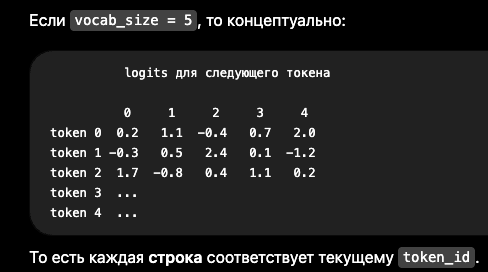

1. Далее в матрице инициализируются случайные числа
2. потом идет обучение: допустим в тексте у нас токены 45, 46, мы подаем токен 45, берем строку 45 из нашей матрицы - [0.3, 4.0 -1.0 ...] которая длины vocab_size и содержит случайные значения
3. далее все идет в softmax и кросс-энтропия сравнивает предсказание с таргетом и вычисляется лосс
4. Затем loss.backward(), optimizer.step() градиентный спуск изменяет значения матрицы так, чтобы в следующий раз предсказание было верным

## То есть идея
Каждый **токен(а точнее его номер)** смотрит на обучающую таблицу(инициализирована рандомно) VxV и берет **строку** из этой таблицы **соответствующую номеру токена**. 
Каждая строка содержит значения(логиты) по каждому токену.

по сути у нас матрица VxV содержит значения всех токенов из словаря

#### Размерность
- B = Batch size — сколько независимых последовательностей обрабатываем одновременно.
- T = Token size / block_size / sequence length — сколько токенов в каждой последовательности.
- C = Channels — здесь это размер выхода для каждого токена, то есть vocab_size.

## Итого
На каждой позиции модель должна выбрать следующий токен из всего словаря. Поэтому она выдаёт vocab_size логитов — по одному score на каждый возможный токен, а после softmax эти логиты превращаются в вероятности.

В моем примере:

C = 65, потому что в словаре 65 токенов, значит для каждой позиции модель выдаёт 65 логитов.

In [14]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [15]:
batch_size = 32
for steps in range(100): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

4.65630578994751


In [16]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


oTo.JUZ!!zqe!
xBP qbs$Gy'AcOmrLwwt
p$x;Seh-onQbfM?OjKbn'NwUAW -Np3fkz$FVwAUEa-wzWC -wQo-R!v -Mj?,SPi


## Математический трюк в self attention

**каждый токен должен уметь собирать информацию из предыдущих токенов через взвешенное усреднение**.

In [17]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3)) # матрица 3 на 3 
# причем это нижняя треугольная матрица - каждый токен может смотреть только на себя и в прошлое.
a = a / torch.sum(a, 1, keepdim=True) # взвешенная сумма - это и есть трюк
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


Обычным предсказанием мы смотрим только на предыдущие токены, а идея в self attention в взвешенных суммах:

***каждый токен должен уметь собирать информацию из предыдущих токенов через взвешенное усреднение.***

Bigram: каждый токен знает только себя -> если просто усреднять:каждый токен получает информацию из всех предыдущих токенов -> Self-Attention:
каждый токен получает информацию из предыдущих токенов, но сам решает, кому уделить больше внимания.

Возьмём совсем простой пример с тремя токенами, у каждого по 2 признака:

token0 = [2, 6]
token1 = [4, 2]
token2 = [8, 4]

Теперь хотим, чтобы token2 получил информацию о себе и предыдущих токенах. В toy-примере Карпати он просто берёт среднее:

$$ \frac{token0 + token1 + token2}{3} $$

Считаем по координатам:

$$ \frac{[2,6] + [4,2] + [8,4]}{3} $$

Сначала складываем:

[2+4+8, 6+2+4] = [14, 12]

Потом делим на 3:

[14/3, 12/3] = [4.67, 4]

То есть новое представление token2 стало:

[4.67, 4]

Смысл такой: раньше token2 содержал только свои признаки:

[8, 4]

а после усреднения он содержит некоторую сводную информацию о token0, token1 и token2.

И вот **self-attention** делает почти то же самое, только не простое среднее 1/3, 1/3, 1/3, а учит разные **веса**. Например:

token2 =
**0.1** * token0 +
**0.7** * token1 +
**0.2** * token2

То есть он сам решает, какая предыдущая информация важнее.

In [18]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [19]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C) берем все токены от начала до текущего t включительно
        xbow[b,t] = torch.mean(xprev, 0) # а затем берем среднее по token_size


In [20]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [21]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [22]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T)) # здесь создаем матрицу весов размера block_size для взвешенного суммиров
wei = wei / wei.sum(1, keepdim=True) # каждая строка нормализуется
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C) # применяем ко всем токенам сразу
torch.allclose(xbow, xbow2)

False

keepdim=True сохраняет размерность (T, 1), чтобы удобно сработал broadcasting при делении каждой строки на её сумму.

In [23]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf')) # тут заполнили вместо нулей на -бесконечность
wei = F.softmax(wei, dim=-1) # а тут применили ко всей матрице softmax чтобы нормализовать
xbow3 = wei @ x # а это по сути агрегация через матричное умножение, каждый токен знает инфу о предыдущих
# но у них одинаковые веса
torch.allclose(xbow, xbow3)



False

In [24]:
print(tril)
print(wei) 
# softmax просто взял суммировал все значения в последовательности и поделил на кол-во
# а так как у нас -inf, то экспонента в степени -inf дает ноль!

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


In [26]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C) # трехмерная матрица

# let's see a single Head perform self-attention
head_size = 16 # это гиперпараметр
key = nn.Linear(C, head_size, bias=False) # создаем 3 матрицы 32x16, то есть переводим 32 --> 16
query = nn.Linear(C, head_size, bias=False) # то есть один и тот же токен представляем в 3 разные матрицы
value = nn.Linear(C, head_size, bias=False) # эти матрицы обучаемые V = X@W
k = key(x)   # (B, T, 16) # для каждого из 8 токенов сделали матрицу b,t,16
q = query(x) # (B, T, 16)

# так как надо сделать скалярное произведение, надо чтоб кол-во строк совпало с кол-во столбцов
# поэтому транспонируем 2 последние размерности
wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T)) # делаем треугольную матрицу, то есть токен можем смотреть только на себя
# и предыдущие токены, но не будущие токены
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf')) # заменяем нули на -бесконечность / будущие токены занулятся
wei = F.softmax(wei, dim=-1)

v = value(x) # еще одна проекция,
# каждый токен получает value — информацию, которую он может передать другим токенам.
# wei = (B,T,T)
# v   = (B,T,16)
out = wei @ v
#out = wei @ x = B, T, 16

out.shape

torch.Size([4, 8, 16])

То есть:

out.shape
// torch.Size([4, 8, 16])

И здесь происходит самое главное.

Допустим для token2:

attention weights =
[0.34, 0.04, 0.62]

Тогда:

$$ out_2 = 0.34v_0 + 0.04v_1 + 0.62v_2 $$

То есть новый вектор token2 содержит информацию:

34% от token0
 4% от token1
62% от себя

И всё это — вектор длины 16.

то есть получается: на вход у нас есть матрица данных, трехмерная - B, T, C у которой B-кол-во батчей, T - кол-во последовательностей, C - кол-во значений в последовательности, она изначально заполняется рандомными значениями и далее от этой матрицы мы делаем еще 3 матрицы с этими же значениями, но с другим размером - количество значений в последовательности становится не C, а head_size, эти матрицы называются Q, K и V, где Q - значение текущего токена, K - значения других токенов, V - значение которое можно передать другим токенам, далее скалярно перемножаем Q на транспонированное K и получаем матрицу B, T, T которая по сути говорит какое отношение имеет друг к другу каждый токен и далее в матрице делаем треугольную матрицу, чтобы токены смотрели только на себя и на прошлые токены и потом применяем softmax чтобы нормализовать и получить вероятности, а далее скалярно перемножаем матрицу вероятностей на матрицу V и получаем токены которые имеют контекст

In [27]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

## Итого

Что важно понимать про Attention

Attention — это механизм обмена информацией между токенами. Каждый токен может посмотреть на другие доступные ему токены, определить, какие из них сейчас важнее, и собрать из них информацию через взвешенную сумму. Если некоторому токену важнее всего другой токен, его attention weight будет больше, и его Value сильнее повлияет на новое представление текущего токена.

Математически это можно представить так:

$$ out_i = \sum_j \alpha_{ij}V_j $$

где $$ (\alpha_{ij}) $$ — вес внимания токена \(i\) к токену \(j\), а \(V_j\) — информация, которую токен \(j\) может передать.

При этом сам механизм attention не знает порядка токенов. Для него вход — просто набор векторов. Он сам по себе не понимает, что один токен был первым, другой вторым, а третий третьим. Поэтому в Transformer отдельно добавляется информация о позиции токена — например, positional embeddings или RoPE.

Важно также, что последовательности внутри batch обрабатываются независимо. Если:

B = 4

то у нас есть 4 отдельные последовательности. Токены внутри первой последовательности могут взаимодействовать друг с другом, но они никогда не взаимодействуют с токенами второй, третьей или четвёртой последовательности.

В autoregressive-моделях вроде GPT используется causal attention. Это значит, что токен может смотреть только на себя и на предыдущие токены:

token 0 -> token 0
token 1 -> token 0, 1
token 2 -> token 0, 1, 2
token 3 -> token 0, 1, 2, 3

Смотреть в будущее нельзя, потому что при генерации будущие токены ещё неизвестны. Для этого используется causal mask, которая ставит -inf на будущие позиции перед softmax.

В encoder-моделях, например BERT, такой маски обычно нет. Поэтому каждый токен может смотреть сразу на всю последовательность — и влево, и вправо. Именно поэтому BERT называют bidirectional-моделью.

Self-attention означает, что Query, Key и Value строятся из одной и той же входной последовательности:

$$ Q=XW_Q $$ $$ K=XW_K $$ $$ V=XW_V $$

То есть последовательность как бы «смотрит сама на себя». Query можно интерпретировать как «что я ищу», Key — «что у меня есть», а Value — «какую информацию я могу передать».

Сначала вычисляется:

$$ QK^T $$

Это даёт матрицу размера \(T \times T\), в которой каждый токен сравнивается с каждым другим токеном. Чем больше значение \(q_i \cdot k_j\), тем больше токен \(i\) хочет обратить внимание на токен \(j\).

После causal mask применяется softmax, и scores превращаются в нормированные attention weights:

scores:
[2.1, 0.3, -0.7, -inf]

↓ softmax

weights:
[0.81, 0.13, 0.06, 0.00]

После этого вычисляется:

$$ Attention = weights \cdot V $$

То есть каждый токен получает взвешенную сумму Value других доступных токенов. В результате его новое пред

In [28]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [29]:
k.var()

tensor(1.0449)

In [30]:
q.var()

tensor(1.0700)

In [31]:
wei.var()

tensor(1.0918)

In [32]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [33]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

## FFN

Attention смешивает информацию между токенами, а Feed-Forward преобразует информацию внутри каждого токена отдельно.

То есть по сути каждый токен получил информацию от других токенов и теперь надо каждому токену индивидуально подумать над ней и подумать можно благодаря FFN, то есть обработать

FFN — “что с этой информацией сделать”.

После self-attention токен уже собрал контекст от других токенов, например:

"it" --> attention --> получил информацию про "cat", "tired", контекст предложения

Но дальше нужно не просто хранить эту смесь, а нелинейно её преобразовать: выделить полезные признаки, комбинировать их, подавить ненужные, построить более сложное представление. Это и делает FFN

## LayerNorm
LayerNorm используется в Transformer, потому что она нормализует признаки внутри каждого токена независимо от размера и состава batch.

In [34]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [35]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

(tensor(0.1469), tensor(0.8803))

In [36]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

In [ ]:
# French to English translation example:

# <--------- ENCODE ------------------><--------------- DECODE ----------------->
# les réseaux de neurones sont géniaux! <START> neural networks are awesome!<END>

